# **Reproduction: Landscapes of Crashes (Gidea & Katz, 2018)**

In [7]:
from utils import (
    generate_white_noise_dataset, generate_gamma_transition_dataset
)

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='white', rc={'axes.grid': False})
plt.rc('axes', grid=False)
colors = sns.color_palette("bright")

import sys
import os
sys.path.append(os.path.abspath('../..'))

from core.time_series import window_landscape_norms

random_seed = 42

## **Relationship between PL Norms and White Noise Variance (Section 3.3)**

In [2]:
realizations = 1000
sigma_range = np.linspace(1.0, 10.0, 10)
mc_data = generate_white_noise_dataset(sigma_values=sigma_range, num_realizations=realizations, seed=random_seed)

# ASSUMPTION / PROXY
mc_t_interval = np.linspace(0, 25.0, 1000)

p1_matrix = np.zeros((realizations, len(sigma_range)))
p2_matrix = np.zeros((realizations, len(sigma_range)))
for j, sigma in enumerate(sigma_range):
    for i, arr in enumerate(mc_data[sigma]):
        p1, p2 = window_landscape_norms(arr, mc_t_interval)
        p1_matrix[i,j] = p1
        p2_matrix[i,j] = p2

p1_norms = np.mean(p1_matrix, axis=0)
p2_norms = np.mean(p2_matrix, axis=0)

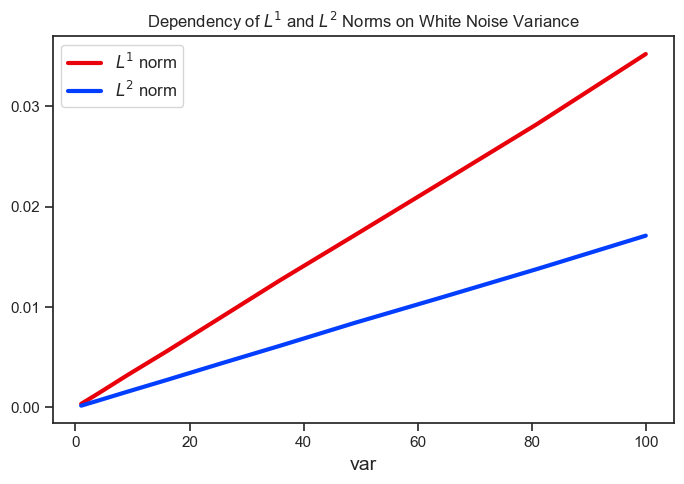

In [8]:
variances = sigma_range ** 2

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(variances, p1_norms, color=colors[3], linewidth=3, label='$L^1$ norm')
ax.plot(variances, p2_norms, color=colors[0], linewidth=3, label='$L^2$ norm')

ax.set_xlabel('var', fontsize=14)
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.tick_params(bottom=True, left=True, length=6, width=1.2)
ax.set_title(r'Dependency of $L^1$ and $L^2$ Norms on White Noise Variance', fontsize=12)
ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

## **Relationship between PL Norms and System State (Section 3.4)**

In [4]:
realizations = 100
steps = 100
gm_data = generate_gamma_transition_dataset(num_realizations=realizations, seed=random_seed)

# ASSUMPTION / PROXY
gm_t_interval = np.linspace(0, 5.0, 1000)

p1_matrix = np.zeros((realizations, steps))
p2_matrix = np.zeros((realizations, steps))
var_matrix = np.zeros((realizations, steps))

for r in range(realizations):
    for s in range(steps):
        arr = gm_data[r][s]
        p1, p2 = window_landscape_norms(arr, gm_t_interval)
        p1_matrix[r, s] = p1
        p2_matrix[r, s] = p2
        var_matrix[r, s] = np.mean(np.var(arr, axis=0))

p1_mean = np.mean(p1_matrix, axis=0)
p2_mean = np.mean(p2_matrix, axis=0)
avg_variance = np.mean(var_matrix, axis=0)

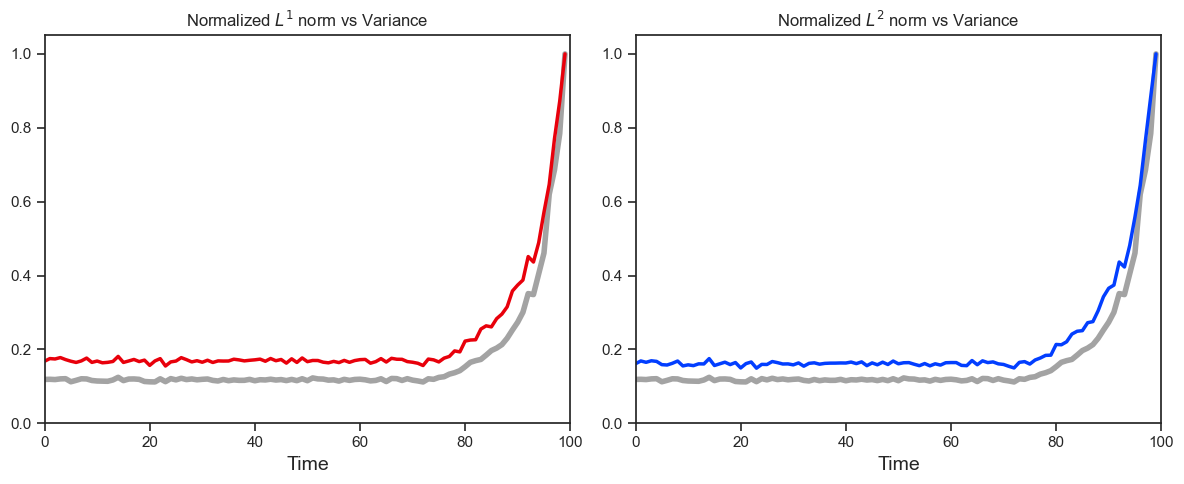

In [9]:
p1_normalized = p1_mean / np.max(p1_mean)
p2_normalized = p2_mean / np.max(p2_mean)
var_normalized = avg_variance / np.max(avg_variance)

time_steps = np.arange(0, steps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: L1 Norm
ax1.plot(time_steps, var_normalized, color=colors[7], linewidth=4.0, zorder=1, label='Average variance')
ax1.plot(time_steps, p1_normalized, color=colors[3], linewidth=2.5, zorder=2, label='Normalized $L^1$-norm')
ax1.set_xlabel('Time', fontsize=14)
ax1.set_xlim(0, 100)
ax1.set_ylim(0.0, 1.05)
ax1.yaxis.set_major_locator(MultipleLocator(0.2))
ax1.tick_params(bottom=True, left=True, length=6, width=1.2)
ax1.set_title(r'Normalized $L^1$ norm vs Variance', fontsize=12)

# Right: L2 Norm
ax2.plot(time_steps, var_normalized, color=colors[7], linewidth=4.0, zorder=1, label='Average variance')
ax2.plot(time_steps, p2_normalized, color=colors[0], linewidth=2.5, zorder=2, label='Normalized $L^2$-norm')
ax2.set_xlabel('Time', fontsize=14)
ax2.set_xlim(0, 100)
ax2.set_ylim(0.0, 1.05)
ax2.yaxis.set_major_locator(MultipleLocator(0.2))
ax2.tick_params(bottom=True, left=True, length=6, width=1.2)
ax2.set_title(r'Normalized $L^2$ norm vs Variance', fontsize=12)

plt.tight_layout()
plt.show()

## **TODO (Section 4)**

In [10]:
data = yf.download(
    ['^GSPC', '^DJI', '^IXIC', '^RUT'], start='1987-12-23', end='2016-12-09'
)

df_close = data['Close']

df_close = df_close.rename(
    columns={
        '^DJI': 'DJIA',
        '^GSPC': 'SP500',
        '^IXIC': 'NASDAQ',
        '^RUT': 'RUSSELL2000',
    }
)

df_close.to_csv('stock_prices.csv')

[*********************100%***********************]  4 of 4 completed


In [11]:
df = pd.read_csv('stock_prices.csv', index_col='Date', parse_dates=True)
print(df.head(3))
print(f"\n{df.count()}")

            DJIA       SP500      NASDAQ  RUSSELL2000
Date                                                 
1987-12-23   NaN  253.160004  331.500000   120.800003
1987-12-24   NaN  252.029999  333.200012   121.589996
1987-12-28   NaN  245.570007  325.600006   119.000000

DJIA           6284
SP500          7301
NASDAQ         7301
RUSSELL2000    7301
dtype: int64


We will drop all dates before January 1st, 1992 to resolve this issue.

In [53]:
returns_df = np.log(df / df.shift(1)).dropna()

returns = returns_df.values
dates = returns_df.index

window_size = [50, 100]
rows = returns.shape[0]

# ASSUMPTION / PROXY
t_interval = np.linspace(0, 0.1, 1000)

p1_50days = np.zeros(rows - 50)
p2_50days = np.zeros(rows - 50)
p1_100days = np.zeros(rows - 100)
p2_100days = np.zeros(rows - 100)

for w in window_size:
    for i in range(rows - w):
        arr = returns[i:(i+w), :]
        p1, p2 = window_landscape_norms(arr, t_interval, scaled=False)

        if w == 50:
            p1_50days[i] = p1
            p2_50days[i] = p2
        if w == 100:
            p1_100days[i] = p1
            p2_100days[i] = p2

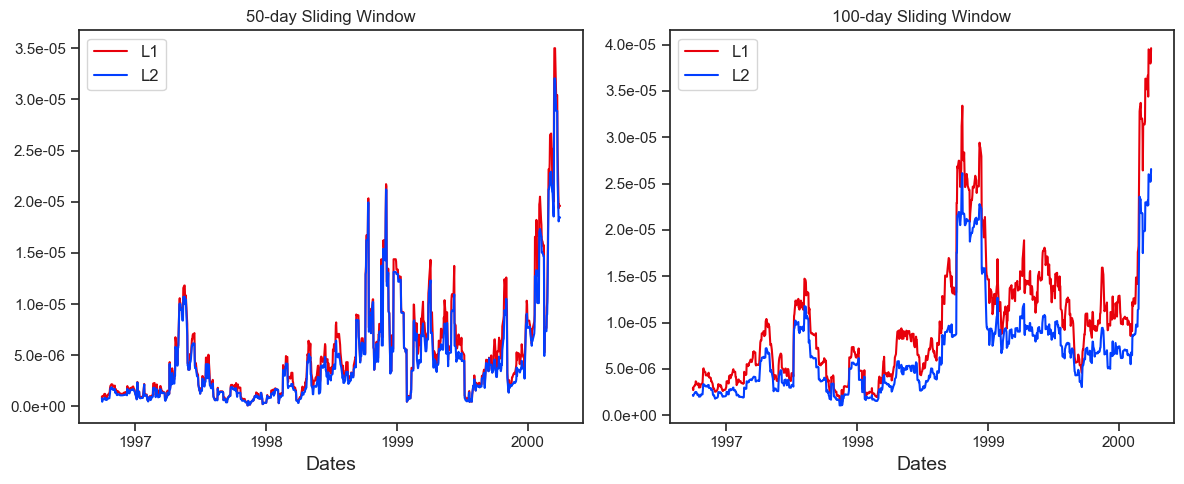

In [54]:
dates_50 = dates[50:]
mask_50 = (dates_50 >= '1996-10-01') & (dates_50 <= '2000-04-01')

sub_dates_50 = dates_50[mask_50]
sub_p1_50 = p1_50days[mask_50]
sub_p2_50 = p2_50days[mask_50]

dates_100 = dates[100:]
mask_100 = (dates_100 >= '1996-10-01') & (dates_100 <= '2000-04-01')

sub_dates_100 = dates_100[mask_100]
sub_p1_100 = p1_100days[mask_100]
sub_p2_100 = p2_100days[mask_100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: w = 50 days
ax1.plot(sub_dates_50, sub_p1_50, color=colors[3], linewidth=1.5, label='L1')
ax1.plot(sub_dates_50, sub_p2_50, color=colors[0], linewidth=1.5, label='L2')
ax1.set_xlabel('Dates', fontsize=14)
ax1.tick_params(bottom=True, left=True, length=6, width=1.2)
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_title('50-day Sliding Window', fontsize=12)
ax1.legend(fontsize=12, loc='upper left')

# Right: w = 100 days
ax2.plot(sub_dates_100, sub_p1_100, color=colors[3], linewidth=1.5, label='L1')
ax2.plot(sub_dates_100, sub_p2_100, color=colors[0], linewidth=1.5, label='L2')
ax2.set_xlabel('Dates', fontsize=14)
ax2.tick_params(bottom=True, left=True, length=6, width=1.2)
ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_title('100-day Sliding Window', fontsize=12)
ax2.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

In [36]:
def min_max_scale(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

def get_1000_days_prior(plot_dates, crash_date_str):
    idx_crash = plot_dates.get_indexer(
        [pd.Timestamp(crash_date_str)], method='nearest'
    )[0]
    return slice(max(0, idx_crash - 1000), idx_crash + 1)

[*********************100%***********************]  1 of 1 completed


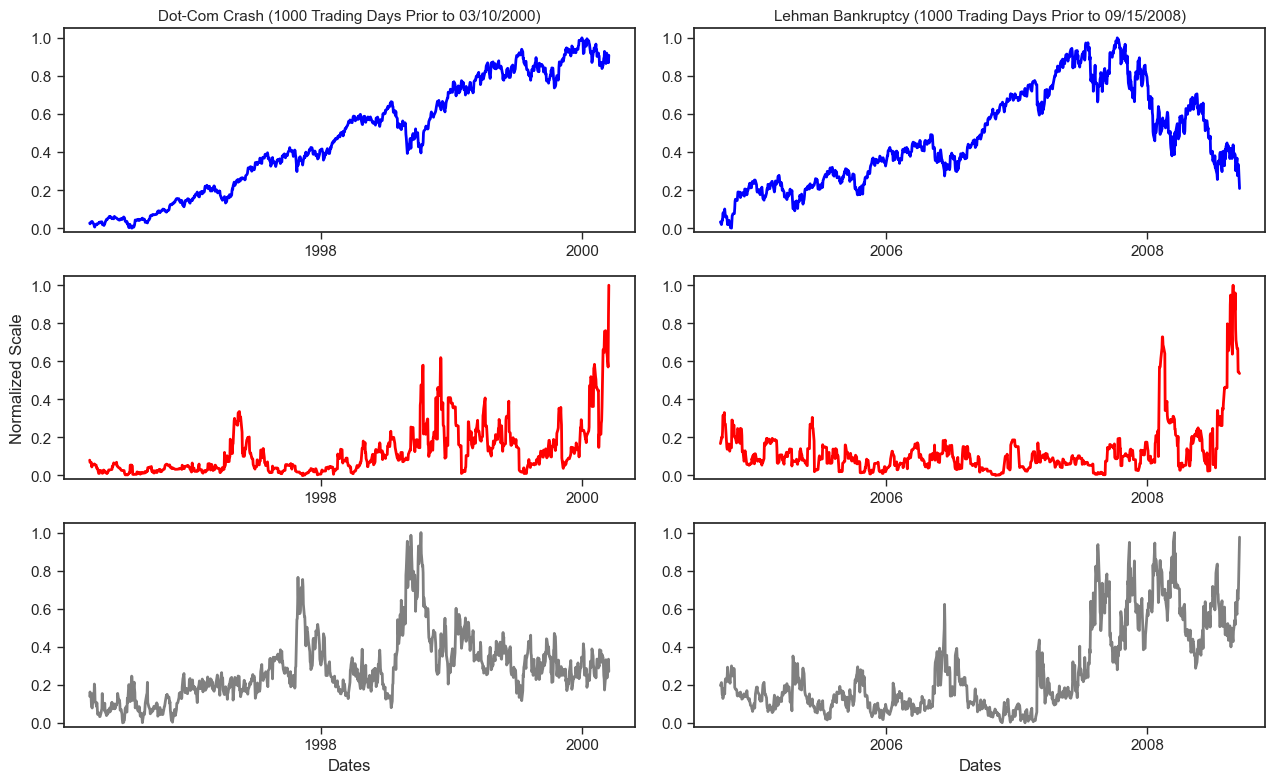

In [55]:
vix = yf.download('^VIX', start='1992-01-01', end='2016-12-09')['Close']
vix_series = vix.iloc[:, 0]

sp500_price = df['SP500']

plot_dates = dates[50:]
sp500_aligned = sp500_price.loc[plot_dates]
vix_aligned = vix_series.loc[plot_dates]

mask_dotcom = get_1000_days_prior(plot_dates, '2000-03-15')
mask_lehman = get_1000_days_prior(plot_dates, '2008-09-15')

fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharey=False)

dates_dotcom = plot_dates[mask_dotcom]

axes[0, 0].plot(
    dates_dotcom,
    min_max_scale(sp500_aligned[mask_dotcom]),
    color='blue',
    linewidth=2,
)
axes[0, 0].set_title(
    "Dot-Com Crash (1000 Trading Days Prior to 03/10/2000)", fontsize=11
)

axes[1, 0].plot(
    dates_dotcom,
    min_max_scale(p1_50days[mask_dotcom]),
    color='red',
    linewidth=2,
)
axes[1, 0].set_ylabel('Normalized Scale', fontsize=12)

axes[2, 0].plot(
    dates_dotcom,
    min_max_scale(vix_aligned[mask_dotcom]),
    color='gray',
    linewidth=2,
)
axes[2, 0].set_xlabel('Dates', fontsize=12)

dates_lehman = plot_dates[mask_lehman]

axes[0, 1].plot(
    dates_lehman,
    min_max_scale(sp500_aligned[mask_lehman]),
    color='blue',
    linewidth=2,
)
axes[0, 1].set_title(
    "Lehman Bankruptcy (1000 Trading Days Prior to 09/15/2008)", fontsize=11
)

axes[1, 1].plot(
    dates_lehman,
    min_max_scale(p1_50days[mask_lehman]),
    color='red',
    linewidth=2,
)

axes[2, 1].plot(
    dates_lehman,
    min_max_scale(vix_aligned[mask_lehman]),
    color='gray',
    linewidth=2,
)
axes[2, 1].set_xlabel('Dates', fontsize=12)

for ax in axes.flat:
    ax.tick_params(bottom=True, left=True, length=5, width=1.0)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()